In [59]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("wfdb")

pandas is installed
matplotlib is installed
numpy is installed
wfdb is installed


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import tensorflow as tf



## Load Data

In [61]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

,RXPACC,FP_IDX,CIR746,CIR740,CIR749,CIR_PWR,CIR750,CIR575,CIR326,CIR333,CIR349,CIR350,CIR246,NLOS,RANGE
0,611.0,745.0,6102.0,266.0,9621.0,11855.0,8303.0,106.0,150.0,182.0,179.0,215.0,284.0,0.0,3.90
1,447.0,749.0,194.0,10.0,1840.0,18968.0,5244.0,245.0,263.0,247.0,123.0,299.0,230.0,0.0,0.66
2,723.0,746.0,1212.0,500.0,4489.0,14699.0,2992.0,73.0,172.0,265.0,205.0,180.0,314.0,1.0,7.86
3,1024.0,750.0,292.0,241.0,1424.0,8748.0,2907.0,418.0,213.0,250.0,157.0,345.0,317.0,1.0,3.48
4,276.0,746.0,11949.0,280.0,16162.0,11380.0,19583.0,185.0,68.0,240.0,42.0,338.0,152.0,0.0,1.19


## Split data 

In [62]:
original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# print(X_train.describe())


# Classification of NLOS and LOS data

## Decision Tree Classification

In [63]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

dtc_y_pred = dtc.predict(X_test)


rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

rfc_y_pred = rfc.predict(X_test)

### Accuracy Testing

In [64]:
print("Decision Tree Classifier Accuracy:",metrics.accuracy_score(y_test, dtc_y_pred))

print("Random Forest Classifier Accuracy:",metrics.accuracy_score(y_test, rfc_y_pred))

Decision Tree Classifier Accuracy: 0.8654761904761905
Random Forest Classifier Accuracy: 0.8929365079365079


## KNN

In [65]:
numNeighbors = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)

    train_accuracy = accuracy_score(y_train, Y_predTrain)
    test_accuracy = accuracy_score(y_test, Y_predTest)

    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'k={k}, Training Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')    

k=1, Training Accuracy: 1.0000, Test Accuracy: 0.7167
k=2, Training Accuracy: 0.8465, Test Accuracy: 0.7370
k=3, Training Accuracy: 0.8587, Test Accuracy: 0.7492
k=4, Training Accuracy: 0.8209, Test Accuracy: 0.7543
k=5, Training Accuracy: 0.8278, Test Accuracy: 0.7536
k=6, Training Accuracy: 0.8072, Test Accuracy: 0.7575
k=7, Training Accuracy: 0.8128, Test Accuracy: 0.7570
k=10, Training Accuracy: 0.7956, Test Accuracy: 0.7640
k=11, Training Accuracy: 0.8001, Test Accuracy: 0.7659
k=12, Training Accuracy: 0.7911, Test Accuracy: 0.7679
k=13, Training Accuracy: 0.7940, Test Accuracy: 0.7694
k=14, Training Accuracy: 0.7878, Test Accuracy: 0.7675
k=15, Training Accuracy: 0.7907, Test Accuracy: 0.7678
k=16, Training Accuracy: 0.7866, Test Accuracy: 0.7670
k=17, Training Accuracy: 0.7878, Test Accuracy: 0.7671
k=18, Training Accuracy: 0.7828, Test Accuracy: 0.7680
k=19, Training Accuracy: 0.7848, Test Accuracy: 0.7695
k=20, Training Accuracy: 0.7814, Test Accuracy: 0.7683
k=25, Training Ac

## Neural Network

hidden_layer_sizes=(5, 5, 5), Training Accuracy: 0.8501, Test Accuracy: 0.8478
hidden_layer_sizes=(6, 6, 6), Training Accuracy: 0.8518, Test Accuracy: 0.8486
hidden_layer_sizes=(7, 7, 7), Training Accuracy: 0.8089, Test Accuracy: 0.8137
hidden_layer_sizes=(10, 10, 10), Training Accuracy: 0.8560, Test Accuracy: 0.8537
hidden_layer_sizes=(20, 20, 20), Training Accuracy: 0.8299, Test Accuracy: 0.8294
hidden_layer_sizes=(30, 30, 30), Training Accuracy: 0.8439, Test Accuracy: 0.8428
hidden_layer_sizes=(40, 40, 40), Training Accuracy: 0.8571, Test Accuracy: 0.8550


Text(0, 0.5, 'Accuracy')

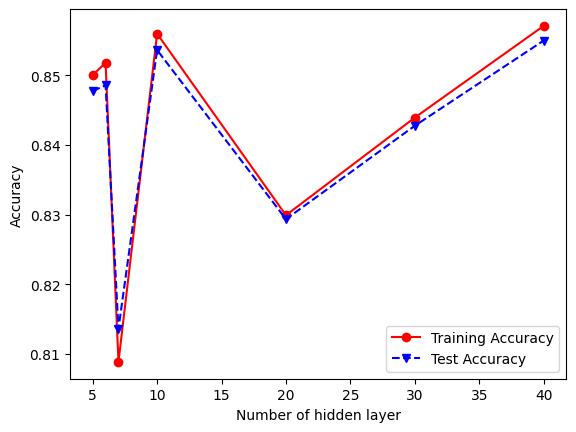

In [66]:
hidden_layer_sizes = [(5,5,5), (6,6,6), (7,7,7),(10,10,10), (20,20,20), (30,30,30), (40,40,40)]
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=k, learning_rate='adaptive',random_state=1,max_iter=1000)
    clf6.fit(X_train, y_train)
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))
    print(f'hidden_layer_sizes={k}, Training Accuracy: {accuracy_score(y_train, Y_predTrain):.4f}, Test Accuracy: {accuracy_score(y_test, Y_predTest):.4f}')
    
hidden_layer_size=[x[0] for x in hidden_layer_sizes]
plt.plot(hidden_layer_size, trainAcc, 'ro-', hidden_layer_size, testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of hidden layer')
plt.ylabel('Accuracy')

# Prediction of range

## Multilinear Regression

In [91]:
file_directory = "./Cleaned_Data"

original_df_range = pd.read_csv(os.path.join(file_directory,"Range_Cleaned_Data.csv"))

original_df_range = original_df_range.drop(columns = ['Unnamed: 0'])

original_df_range.head()

X = original_df_range.drop(['RANGE'], axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.4, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(X_train_range, y_train_range) 

y_pred_range = regr.predict(X_test_range)


### Accuracy Testing

In [92]:
# Evaluate the model
mse = mean_squared_error(y_test_range, y_pred_range)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 3.3664
R-squared: 0.3879


## Neural Networks

In [93]:
ann = tf.keras.models.Sequential()

ann.add(tf.keras.layers.Dense(units=64, activation='relu'))  # Increased neurons
ann.add(tf.keras.layers.Dense(units=128, activation='relu'))  # New layer
ann.add(tf.keras.layers.Dense(units=64, activation='relu'))  # New layer
ann.add(tf.keras.layers.Dense(units=1))  # Output layer remains the same

scaler = StandardScaler()
scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train_range)
X_test_scaled = scaler_X.transform(X_test_range)

# Fit and transform the target variable
y_train_scaled = scaler_y.fit_transform(y_train_range.values.reshape(-1, 1)) 
y_test_scaled = scaler_y.transform(y_test_range.values.reshape(-1, 1)) 


ann.compile(optimizer = 'adam', loss = 'mean_squared_error',metrics=['mean_absolute_error', 'mean_squared_error'])

model = ann.fit(X_train_scaled, y_train_scaled, 
                batch_size=32, 
                epochs=25,
                validation_data=(X_test_scaled, y_test_scaled),  # Validation data should be test data
                shuffle=True)



Epoch 1/25
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5788 - mean_absolute_error: 0.5997 - mean_squared_error: 0.5788 - val_loss: 0.4993 - val_mean_absolute_error: 0.5588 - val_mean_squared_error: 0.4993
Epoch 2/25
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4872 - mean_absolute_error: 0.5482 - mean_squared_error: 0.4872 - val_loss: 0.4802 - val_mean_absolute_error: 0.5464 - val_mean_squared_error: 0.4802
Epoch 3/25
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4773 - mean_absolute_error: 0.5382 - mean_squared_error: 0.4773 - val_loss: 0.4604 - val_mean_absolute_error: 0.5323 - val_mean_squared_error: 0.4604
Epoch 4/25
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4420 - mean_absolute_error: 0.5196 - mean_squared_error: 0.4420 - val_loss: 0.4554 - val_mean_absolute_error: 0.5246 - val_mean_squared_error: 0.4554
Epoch 5/25
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4380 - mean_absolute_error: 0.5159 - mean_squared_error: 0.4380 - val_loss: 0.4598 - val_m

In [94]:
y_test_pred_scaled = model.model.predict(X_test_scaled)

# Reverse the scaling for predictions to get the original scale
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# Reverse the scaling for the true values to get the original scale
y_test_true = scaler_y.inverse_transform(y_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

# Print results
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step
Mean Squared Error (MSE): 2.6451
R² Score: 0.5191


## Random Forest Regression

In [ ]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)

regressor.fit(X_train_range, y_train_range)

y_pred_range = regressor.predict(X_test_range)

mse = mean_squared_error(y_test_range, y_pred_range)
r2 = r2_score(y_test_range, y_pred_range)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")